# Taller DIGD MovieLens

## Información importante del README

MovieLens data sets were collected by the GroupLens Research Project
at the University of Minnesota.

This data set consists of:
* 100,000 ratings (1-5) from 943 users on 1682 movies.
* Each user has rated at least 20 movies.
    * Simple demographic info for the users (age, gender, occupation, zip)

The data was collected through the MovieLens web site
(movielens.umn.edu) during the seven-month period from September 19th,
1997 through April 22nd, 1998. This data has been cleaned up - users
who had less than 20 ratings or did not have complete demographic
information were removed from this data set.

## Librerías e importación de los datos

### Librerías


In [201]:
import pandas as pd

In [202]:
import zipfile
from pathlib import Path

### Importar zip


In [203]:
FILES_TO_EXTRACT = ["u.data", "u.info", "u.item", "u.genre", "u.user", "u.occupation"]
DATA_DIR_NAME = "data/raw"

In [204]:
def extract_data_from_zip(zip_name, target_dir_name):
    zip_path = Path(zip_name)
    target_dir = zip_path.parent / target_dir_name
    target_dir.mkdir(exist_ok=True)

    with zipfile.ZipFile(zip_path, "r") as archive:
        for file_name_w_directory in archive.namelist():
            file_name = Path(file_name_w_directory).name
            if file_name in FILES_TO_EXTRACT:
                destination_path = target_dir / file_name
                with archive.open(file_name_w_directory) as source_file:
                    with open(destination_path, "wb") as target_file:
                        target_file.write(source_file.read())
                print(f"Extracted: {file_name} to {destination_path}")

In [205]:
extract_data_from_zip("../ml-100k.zip", DATA_DIR_NAME)

Extracted: u.data to ..\data\raw\u.data
Extracted: u.genre to ..\data\raw\u.genre
Extracted: u.info to ..\data\raw\u.info
Extracted: u.item to ..\data\raw\u.item
Extracted: u.occupation to ..\data\raw\u.occupation
Extracted: u.user to ..\data\raw\u.user


## Calidad de los datos

Para cada tabla (data, info, item, genre, user, occupation) se importan los datos como dataframe, se hecha un vistazo y se inspeccionan valores no nulos y tipos por columna. Luego se revisan duplicados, que las fechas sean correctas, etc.

### Data

* The full u data set, 100000 ratings by 943 users on 1682 items. Each user has rated at least 20 movies.
* Users and items are numbered consecutively from 1.
* The data is randomly ordered.
* This is a tab separated list of **user id | item id | rating | timestamp**.
* The time stamps are unix seconds since 1/1/1970 UTC

In [206]:
data = pd.read_csv("../" + DATA_DIR_NAME+"/u.data", sep="\t", names=["user_id", "item_id", "rating", "timestamp"])
data.head()

,user_id,item_id,rating,timestamp
0,196,242,3,881250949
1,186,302,3,891717742
2,22,377,1,878887116
3,244,51,2,880606923
4,166,346,1,886397596


In [207]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype
---  ------     --------------   -----
 0   user_id    100000 non-null  int64
 1   item_id    100000 non-null  int64
 2   rating     100000 non-null  int64
 3   timestamp  100000 non-null  int64
dtypes: int64(4)
memory usage: 3.1 MB


Se crea una nueva columna con la fecha y tiempo en que se hizo la reseña a partir de la columna de marca de tiempo ('timestamp')

In [208]:
data['datetime'] = pd.to_datetime(data['timestamp'], unit='s')
data.head()

,user_id,item_id,rating,timestamp,datetime
0,196,242,3,881250949,1997-12-04 15:55:49
1,186,302,3,891717742,1998-04-04 19:22:22
2,22,377,1,878887116,1997-11-07 07:18:36
3,244,51,2,880606923,1997-11-27 05:02:03
4,166,346,1,886397596,1998-02-02 05:33:16


Sí hay 100,000 calificaciones

In [209]:
print(f"Cantidad de calificaciones: {data.shape[0]}")

Cantidad de calificaciones: 100000


Las calificaciones sí están entre 1 y 5

In [210]:
print(f"Calificaciones: {data['rating'].sort_values().unique()}")

Calificaciones: [1 2 3 4 5]


Sí hay 943 usuarios que dieron alguna calificación

In [211]:
print(f"Usuarios que dieron una calificación: {data['user_id'].unique().shape[0]}")

Usuarios que dieron una calificación: 943


Sí hay 1682 películas calificadas

In [212]:
print(f"Películas calificadas: {data['item_id'].unique().shape[0]}")

Películas calificadas: 1682


Todos los usuarios han calificado por lo menos 20 películas

In [213]:
user_item_counts = data.groupby('user_id')['item_id'].count()
print(f"Todos los usuarios han calificado por lo menos 20 películas: {(user_item_counts >= 20).all()}")

Todos los usuarios han calificado por lo menos 20 películas: True


Las calificaciones están entre el 19 de septiembre de 1997 y el 22 de abril de 1998

In [214]:
datetime = pd.to_datetime(data['timestamp'], unit='s')
print(f"Timestamps are from {datetime.min()} through {datetime.max()}")

Timestamps are from 1997-09-20 03:05:10 through 1998-04-22 23:10:38


### Info

* The number of users, items, and ratings in the u data set.

In [215]:
info = pd.read_csv("../" + DATA_DIR_NAME+"/u.info", sep=" ", names=["info", "value"])
info.head()

,info,value
0,943,users
1,1682,items
2,100000,ratings


In [216]:
info.info()

<class 'pandas.DataFrame'>
RangeIndex: 3 entries, 0 to 2
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   info    3 non-null      int64
 1   value   3 non-null      str  
dtypes: int64(1), str(1)
memory usage: 180.0 bytes


### Item

* Information about the items (movies)
* This is a tab separated list of **movie id | movie title | release date | video release date | IMDb URL | unknown | Action | Adventure | Animation | Children's | Comedy | Crime | Documentary | Drama | Fantasy | Film-Noir | Horror | Musical | Mystery | Romance | Sci-Fi | Thriller | War | Western**.
* The last 19 fields are the genres, a 1 indicates the movie is of that genre, a 0 indicates it is not; movies can be in several genres at once.
* The movie ids are the ones used in the u.data data set.

In [217]:
item = pd.read_csv("../" + DATA_DIR_NAME+"/u.item", sep="|", index_col=None, encoding="latin1",
                   names=["movie id", "movie title", "release date", "video release date",
                          "IMDb URL", "unknown", "Action", "Adventure", "Animation",
                          "Children's", "Comedy", "Crime", "Documentary", "Drama",
                          "Fantasy", "Film-Noir", "Horror", "Musical", "Mystery",
                          "Romance", "Sci-Fi", "Thriller", "War", "Western"])
item.head()

,movie id,movie title,release date,video release date,IMDb URL,unknown,Action,Adventure,Animation,Children's,...,Fantasy,Film-Noir,Horror,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
0,1,Toy Story (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Toy%20Story%2...,0,0,0,1,1,...,0,0,0,0,0,0,0,0,0,0
1,2,GoldenEye (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?GoldenEye%20(...,0,1,1,0,0,...,0,0,0,0,0,0,0,1,0,0
2,3,Four Rooms (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Four%20Rooms%...,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
3,4,Get Shorty (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Get%20Shorty%...,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,5,Copycat (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Copycat%20(1995),0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0


In [218]:
item.info()

<class 'pandas.DataFrame'>
RangeIndex: 1682 entries, 0 to 1681
Data columns (total 24 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   movie id            1682 non-null   int64  
 1   movie title         1682 non-null   str    
 2   release date        1681 non-null   str    
 3   video release date  0 non-null      float64
 4   IMDb URL            1679 non-null   str    
 5   unknown             1682 non-null   int64  
 6   Action              1682 non-null   int64  
 7   Adventure           1682 non-null   int64  
 8   Animation           1682 non-null   int64  
 9   Children's          1682 non-null   int64  
 10  Comedy              1682 non-null   int64  
 11  Crime               1682 non-null   int64  
 12  Documentary         1682 non-null   int64  
 13  Drama               1682 non-null   int64  
 14  Fantasy             1682 non-null   int64  
 15  Film-Noir           1682 non-null   int64  
 16  Horror           

Sí hay 1682 películas

In [219]:
print(f"Cantidad de películas: {item.shape[0]}")

Cantidad de películas: 1682


Todas las películas pertenecen por lo menos a una categoría

In [220]:
print(f"Películas que no pertenecen a ninguna categoría: {item[item.iloc[:, 5:].sum(axis=1) == 0].shape[0]}")

Películas que no pertenecen a ninguna categoría: 0


Las columnas de categoría solo contienen los valores 0 y 1

In [221]:
unique_values_categories = set()
for i in range(5, 24):
    unique_values_categories.update(item.iloc[:, i].unique())
print(f"Valores en las columnas de categoría: {list(map(lambda x: int(x), unique_values_categories))}")

Valores en las columnas de categoría: [0, 1]


Hay una película con el título 'unknown', que realmente no representa ninguna película

In [222]:
print(f"Películas con título 'unknown': {item[item['movie title'] == 'unknown'].shape[0]}")

Películas con título 'unknown': 1


Se cambia el tipo de dato de 'release date' a datetime para poder manipularlo más fácilmente

In [223]:
item["release date"] = pd.to_datetime(item['release date'], format='%d-%b-%Y')

Hay reseñas con fecha previa a la fecha de lanzamiento de la película calificada

In [224]:
# se unen 'data' y 'item' através del identificador de la película
data_item = data[['item_id', 'datetime']].merge(item[['movie id', 'release date']], left_on='item_id', right_on='movie id', how='left')
print(f"Reseñas con fecha previa al lanzamiento de la película: {data_item[data_item['datetime'] < data_item['release date']].shape[0]}")

Reseñas con fecha previa al lanzamiento de la película: 231


Se eliminan las reseñas con fecha previa a la fecha de lanzamiento de la película

In [225]:
data = data[data_item['datetime'] >= data_item['release date']]

Se eliminan todas las películas que no tengan alguna calificación

In [226]:
item = item[item['movie id'].isin(data['item_id'].unique())]

La única película sin 'release date' fue eliminada. También fue eliminada la película 'unknown' sin información.

In [227]:
print(f"Películas sin 'release date': {item['release date'].isna().sum()}")
print(f"Películas con título 'unknown': {item[item['movie title'] == 'unknown'].shape[0]}")

Películas sin 'release date': 0
Películas con título 'unknown': 0


La columna 'movie title' no solo contiene valores únicos. Es decir, hay películas repetidas.

In [228]:
print(f"Hay valores repetidos: {not item["movie title"].is_unique}")

Hay valores repetidos: True


Se eliminan los duplicados exactos. Hay 1661 registros únicos

In [229]:
item_no_duplicates = item.drop_duplicates(subset="movie title", keep="first")
print(f"Hay duplicados: {not item_no_duplicates["movie title"].is_unique}")
print(f"Total registros únicos: {item_no_duplicates.shape[0]}")

Hay duplicados: False
Total registros únicos: 1661


Inicialmente, parece que ningún usuario calificó una película más de una vez

In [230]:
# Se seleccionan las parejas de usuario y película duplicadas.
print(f"Parejas de usuario y película duplicadas: {data[data.duplicated(subset=['user_id', 'item_id'], keep=False)].shape[0]}")

Parejas de usuario y película duplicadas: 0


Se actualizan los IDs de los peliculas duplicadas en la tabla 'data' de acuerdo a las anteriores eliminaciones de duplicados en 'item'.

En data se cambian los IDs de películas que aparecieron duplicadas en 'item' por el primer ID correspondiente a cada título duplicado.

In [231]:
item_copy = item.copy()
item_copy['id'] = item_copy['movie id']
movie_id_mapper = item_copy.set_index('id').groupby('movie title')['movie id'].transform('first')

data['item_id'] = data['item_id'].map(movie_id_mapper)
data['item_id'] = data['item_id'].astype(int)

Tras esta modificación de 'data', resulta que si hay usuarios que calificaron una película más de una vez.

In [232]:
print(f"Parejas de usuario y película duplicadas: {data[data.duplicated(subset=['user_id', 'item_id'], keep=False)].shape[0]}")

Parejas de usuario y película duplicadas: 610


Se asume que cada vez que un usuario volvió a calificar una película representa una actualización de la calificación que indicó inicialmente, de forma que se mantiene únicamente la última calificación que dio cada usuario a cada película

In [233]:
data = data.sort_values(by=['user_id', 'item_id', 'timestamp']).drop_duplicates(subset=['user_id', 'item_id'], keep='last')

Tras esto, resulta que no todos los usuarios calificaron por lo menos 20 películas distintas

In [234]:
user_item_counts = data.groupby('user_id')['item_id'].count()
print(f"Usuarios que calificaron menos de 20 películas: {user_item_counts[user_item_counts < 20].shape[0]}")
print(f"Cantidad mínima de películas calificadas por un usuario: {user_item_counts.min()}")

Usuarios que calificaron menos de 20 películas: 11
Cantidad mínima de películas calificadas por un usuario: 19


La cantidad de películas en 'data' coincide ahora con la cantidad de películas en 'item'

In [235]:
item = item_no_duplicates.copy()
same_number_movies = data["item_id"].unique().shape[0] == item["movie id"].unique().shape[0]
print(f"La cantidad de películas en 'data' e 'item' coinciden: {same_number_movies}")

La cantidad de películas en 'data' e 'item' coinciden: True


La cantidad de calificaciones y películas cambió, pero no la de usuarios

In [236]:
print(f"Cantidad de calificaciones (antes 100000): {data.shape[0]}")
print(f"Cantidad de películas (antes 1682): {item.shape[0]}")
print(f"Cantidad de usuarios (antes 943): {data['user_id'].unique().shape[0]}")

Cantidad de calificaciones (antes 100000): 99455
Cantidad de películas (antes 1682): 1661
Cantidad de usuarios (antes 943): 943


Se eliminan 'video release date' y 'IMDb URL', puesto que 'video release date' es una columna llena de datos faltantes, y 'IMDb URL' no aporta información relevante para un posible futuro modelo de predicción ni para entender los datos.

In [237]:
item = item.drop(columns=['video release date', 'IMDb URL'])

Hay un registro con categoría 'unknown', pero sí corresponde a una película (Good Morning)

In [238]:
item[item["unknown"] == 1]

,movie id,movie title,release date,unknown,Action,Adventure,Animation,Children's,Comedy,Crime,...,Fantasy,Film-Noir,Horror,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
1372,1373,Good Morning (1971),1971-02-04,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


### Genre

* A list of the genres.

In [239]:
genre = pd.read_csv("../" + DATA_DIR_NAME+"/u.genre", sep="|", index_col=0, names=["genre", "value"])
genre

,value
genre,
unknown,0
Action,1
Adventure,2
Animation,3
Children's,4
Comedy,5
Crime,6
Documentary,7
Drama,8


In [240]:
genre.info()

<class 'pandas.DataFrame'>
Index: 19 entries, unknown to Western
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   value   19 non-null     int64
dtypes: int64(1)
memory usage: 304.0+ bytes


Hay 18 géneros concretos, y uno "desconocido".

Los nombres de los géneros de las películas coinciden entre las tablas 'item' y 'genre'

In [241]:
# print(f"Los géneros de las películas coinciden entre 'item' y 'genre': {(item.columns[5:24] == genre.index).all()}")

### User

* Demographic information about the users.
* This is a tab separated list of **user id | age | gender | occupation | zip code**.
* The user ids are the ones used in the u.data data set.

In [242]:
user = pd.read_csv("../" + DATA_DIR_NAME+"/u.user", sep="|", index_col=0, names=["user_id", "age", "gender", "occupation", "zip_code"])
user.head()

,age,gender,occupation,zip_code
user_id,,,,
1,24,M,technician,85711
2,53,F,other,94043
3,23,M,writer,32067
4,24,M,technician,43537
5,33,F,other,15213


In [243]:
user.info()

<class 'pandas.DataFrame'>
RangeIndex: 943 entries, 1 to 943
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   age         943 non-null    int64
 1   gender      943 non-null    str  
 2   occupation  943 non-null    str  
 3   zip_code    943 non-null    str  
dtypes: int64(1), str(3)
memory usage: 29.6 KB


Sí hay 943 usuarios

In [244]:
print(f"Cantidad de usuarios: {user.shape[0]}")

Cantidad de usuarios: 943


Los usuarios tienen información demográfica completa

In [245]:
users_na = user.isna().sum().sum()
print(f"Cantidad de valores nulos en 'user': {users_na}")

Cantidad de valores nulos en 'user': 0


Hay duplicados (por 'age', 'gender', 'occupation' y 'zip_code'). Pero no necesariamente corresponden a la misma persona puesto que el código postal identifica una zona (posiblemente con varias viviendas), no una vivienda específica. Por esto no se eliminan

In [246]:
print(f"Usuarios con mismos atributos: {user[user.duplicated()].shape[0]}")

Usuarios con mismos atributos: 7


Hay dos géneros: M, masculino; F, femenino

In [247]:
print(f"Géneros de los usuarios: {user['gender'].unique()}")

Géneros de los usuarios: <StringArray>
['M', 'F']
Length: 2, dtype: str


No hay valores peculiares de edad

In [248]:
print(f"Edad mínima de los usuarios: {user['age'].min()}")
print(f"Edad máxima de los usuarios: {user['age'].max()}")

Edad mínima de los usuarios: 7
Edad máxima de los usuarios: 73


### Occupation

* A list of the occupations.

In [249]:
occupation = pd.read_csv("../" + DATA_DIR_NAME+"/u.occupation", sep="|", index_col=0, names=["occupation"])
occupation

""
occupation
administrator
artist
doctor
educator
engineer
entertainment
executive
healthcare
homemaker


In [250]:
occupation.info()

<class 'pandas.DataFrame'>
Index: 21 entries, administrator to writer
Empty DataFrame


Hay 18 ocupaciones concretas, las otras 3 son: retirado, otro, y ninguno.

Los nombres de las ocupaciones coinciden entre las tablas 'user' y 'occupation'.

In [251]:
print(f"Las ocupaciones coinciden entre 'user' y 'occupation': {set(user["occupation"].unique()) == set(occupation.index)}")

Las ocupaciones coinciden entre 'user' y 'occupation': True


## Exploración de los datos y estadísticas principales

No quedarán todos al final, esto es solo para comprender la distribución de los datos.

Data



* stats of number of rated movies per user [min, max, median, mean, histogram]


In [253]:
def print_stats(serie, label):
    print(f"--- {label} ---")
    print(f"Mínimo:  {serie.min():.2f}")
    print(f"Máximo:  {serie.max():.2f}")
    print(f"Mediana: {serie.median():.2f}")
    print(f"Media:   {serie.mean():.2f}")

--- Películas calificadas por usuario ---
Mínimo:  19.00
Máximo:  734.00
Mediana: 64.00
Media:   105.47


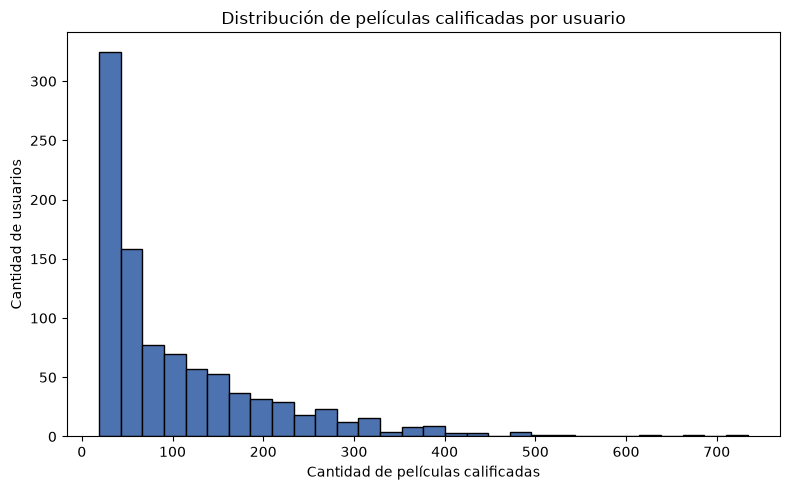

In [255]:
import matplotlib.pyplot as plt
ratings_per_user = data.groupby('user_id')['item_id'].count()
print_stats(ratings_per_user, "Películas calificadas por usuario")

plt.figure(figsize=(8, 5))
plt.hist(ratings_per_user, bins=30, color="#4C72B0", edgecolor="black")
plt.xlabel("Cantidad de películas calificadas")
plt.ylabel("Cantidad de usuarios")
plt.title("Distribución de películas calificadas por usuario")
plt.tight_layout()
plt.show()

* stats of number of ratings per movie [min, max, median, mean, histogram]


--- Calificaciones por película ---
Mínimo:  1.00
Máximo:  583.00
Mediana: 27.00
Media:   59.88


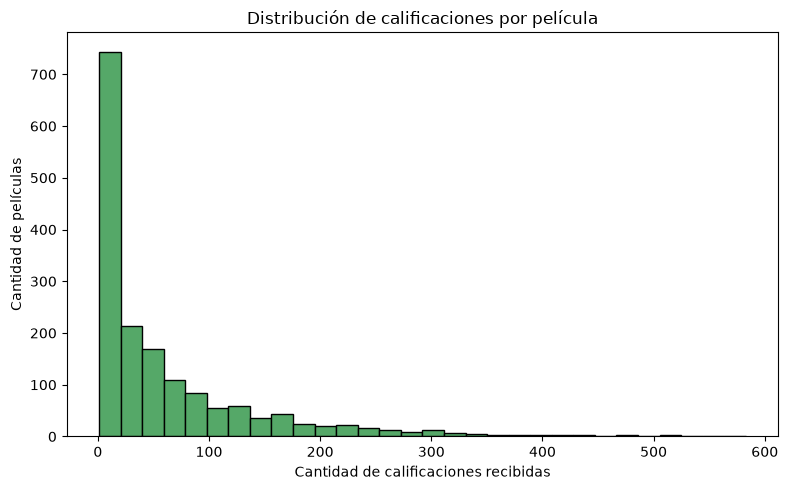

In [256]:
ratings_per_movie = data.groupby('item_id')['user_id'].count()
print_stats(ratings_per_movie, "Calificaciones por película")

plt.figure(figsize=(8, 5))
plt.hist(ratings_per_movie, bins=30, color="#55A868", edgecolor="black")
plt.xlabel("Cantidad de calificaciones recibidas")
plt.ylabel("Cantidad de películas")
plt.title("Distribución de calificaciones por película")
plt.tight_layout()
plt.show()

* stats of ratings [bar plot with absolute counts and proportions]


In [257]:
rating_counts = data['rating'].value_counts().sort_index()
rating_props = data['rating'].value_counts(normalize=True).sort_index()

rating_summary = pd.DataFrame({
    "conteo": rating_counts,
    "proporcion": rating_props.round(4)
})
rating_summary

,conteo,proporcion
rating,,
1,6063,0.0610
2,11326,0.1139
3,27025,0.2717
4,33977,0.3416
5,21064,0.2118


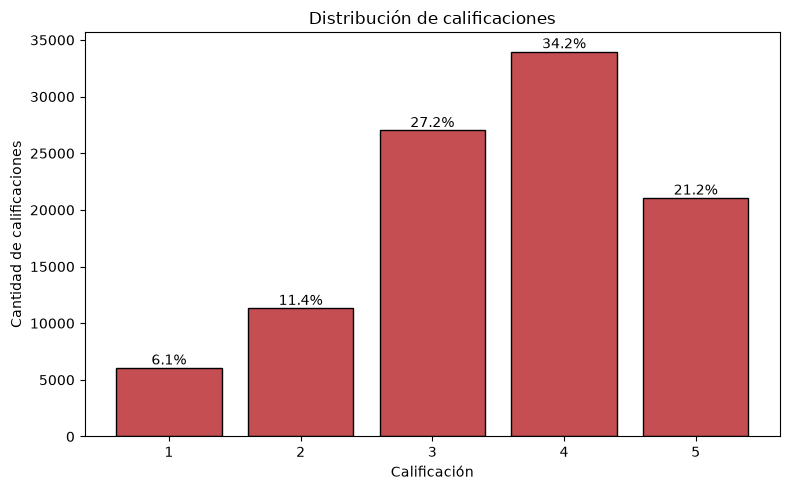

In [258]:
fig, ax1 = plt.subplots(figsize=(8, 5))

bars = ax1.bar(rating_counts.index, rating_counts.values, color="#C44E52", edgecolor="black")
ax1.set_xlabel("Calificación")
ax1.set_ylabel("Cantidad de calificaciones")
ax1.set_title("Distribución de calificaciones")
ax1.set_xticks(rating_counts.index)

for bar, prop in zip(bars, rating_props.values):
    ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
             f"{prop:.1%}", ha="center", va="bottom")

plt.tight_layout()
plt.show()

* stats of average ratings per user [min, max, median, mean, histogram]


--- Calificación promedio por usuario ---
Mínimo:  1.50
Máximo:  4.87
Mediana: 3.62
Media:   3.59


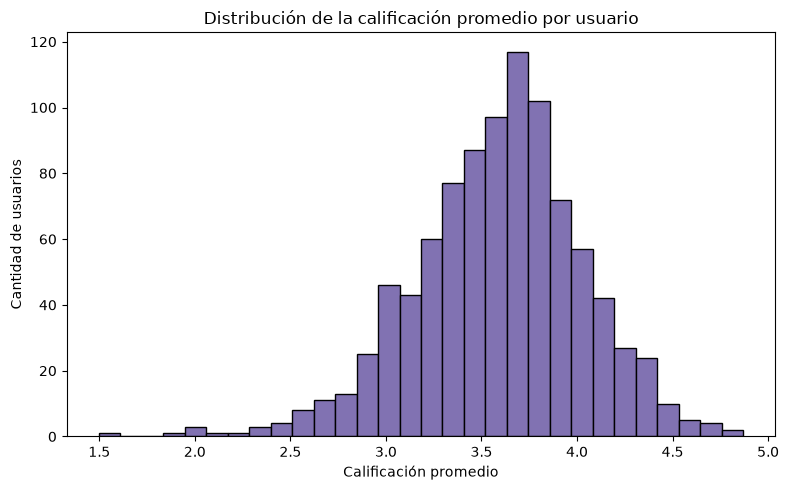

In [259]:
avg_rating_per_user = data.groupby('user_id')['rating'].mean()
print_stats(avg_rating_per_user, "Calificación promedio por usuario")

plt.figure(figsize=(8, 5))
plt.hist(avg_rating_per_user, bins=30, color="#8172B2", edgecolor="black")
plt.xlabel("Calificación promedio")
plt.ylabel("Cantidad de usuarios")
plt.title("Distribución de la calificación promedio por usuario")
plt.tight_layout()
plt.show()

* stats of average ratings per movie [min, max, median, mean, histogram]

--- Calificación promedio por película ---
Mínimo:  1.00
Máximo:  5.00
Mediana: 3.16
Media:   3.08


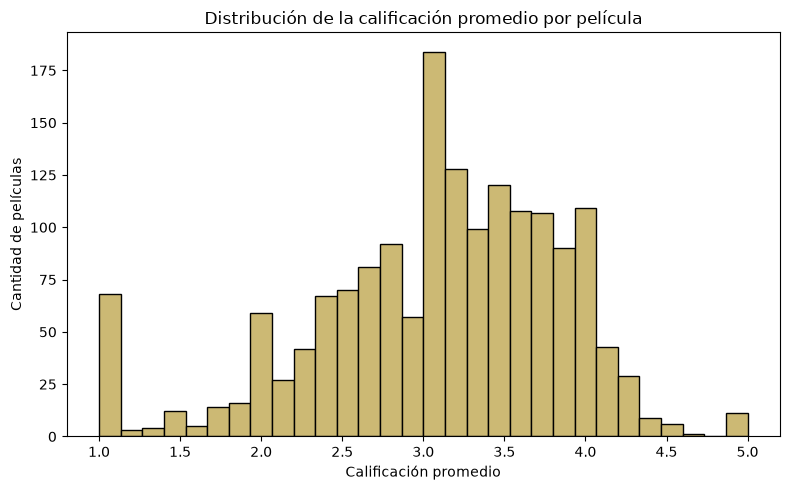

In [260]:
avg_rating_per_movie = data.groupby('item_id')['rating'].mean()
print_stats(avg_rating_per_movie, "Calificación promedio por película")

plt.figure(figsize=(8, 5))
plt.hist(avg_rating_per_movie, bins=30, color="#CCB974", edgecolor="black")
plt.xlabel("Calificación promedio")
plt.ylabel("Cantidad de películas")
plt.title("Distribución de la calificación promedio por película")
plt.tight_layout()
plt.show()

Item

* count of movies per year (release date) [time series plot]


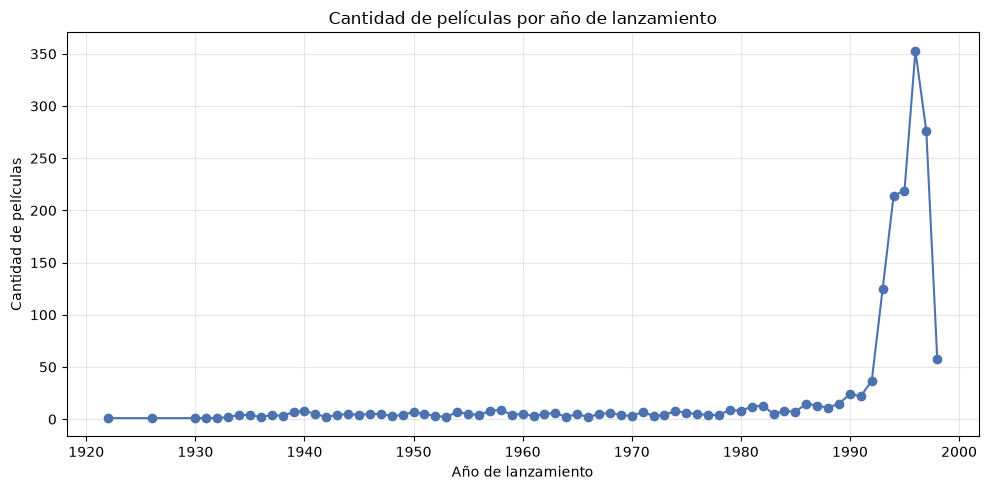

In [261]:
movies_per_year = item['release date'].dt.year.value_counts().sort_index()

plt.figure(figsize=(10, 5))
plt.plot(movies_per_year.index, movies_per_year.values, marker="o", color="#4C72B0")
plt.xlabel("Año de lanzamiento")
plt.ylabel("Cantidad de películas")
plt.title("Cantidad de películas por año de lanzamiento")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

* stats of number of movies per genre, and proportions [bar plot with absolute values and proportions]

In [262]:
genre_columns = ["unknown", "Action", "Adventure", "Animation", "Children's", "Comedy",
                  "Crime", "Documentary", "Drama", "Fantasy", "Film-Noir", "Horror",
                  "Musical", "Mystery", "Romance", "Sci-Fi", "Thriller", "War", "Western"]

movies_per_genre = item[genre_columns].sum().sort_values(ascending=False)
genre_props = movies_per_genre / item.shape[0]

genre_summary = pd.DataFrame({
    "conteo": movies_per_genre,
    "proporcion": genre_props.round(4)
})
genre_summary

,conteo,proporcion
Drama,714,0.4299
Comedy,502,0.3022
Action,249,0.1499
Thriller,247,0.1487
Romance,244,0.1469
Adventure,133,0.0801
Children's,120,0.0722
Crime,107,0.0644
Sci-Fi,100,0.0602
Horror,90,0.0542


User

* distribution of age [min, max, median, mean, histogram]
* proportion of gender [table with proportions]
* proportion of occupation [bar plot with absolute values and proportions]
* distribution of age for gender [overlaid density plots]

Data - Item
* mean ratings per genre [bar plot of means with error bars]

Data - User
* count of ratings per age [min, max, mean, histogram for age intervals]
* ratings x age [violin plot using ratings and age]

* proportion of number of ratings per gender [table with proportions]
* ratings x gender [bar (count) plot with the 5 ratings, and the gender for each]

* count of ratings per occupation, and proportions [bar plot with absolute values and proportions]
* stats of ratings per occupation [bar plot of means with error bars]

Data - Item - User
*

## Conclusions